# European Options

European options give the holder the right but not the obligation to purchase(call)/sell(put) the underlying asset at the option maturity. The pricing of the option is entirely determined by conditional expectation of the payoff.

In [ ]:
# Libraries and path
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))
FIGURE_DIR = Path.cwd().parent / "docs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Core
from derivlab.core.enums import OptionKind

# Product and Model
from derivlab import BlackScholesModel, EuropeanOption, MarketParams

# Pricer
# Analytical
from derivlab.pricers.analytic.black_scholes import BlackScholesAnalyticPricer

# MC
from derivlab.pricers.monte_carlo.engine import MonteCarloPricer, SimulationConfig
from derivlab.pricers.monte_carlo.variance_reduction import (
                                                                AntitheticMonteCarloPricer,
                                                                ControlVariatePricer,
                                                                ControlVariateType,
                                                                StratifiedMonteCarloPricer,
                                                                StratifiedSamplingConfig
                                                            )

# PDE
from derivlab.pricers.pde.black_scholes_pde import BlackScholesPDEPricer
from derivlab.pricers.pde.grids import GridConfig

## Setup

In [64]:
# Black Scholes Framework
market = MarketParams(spot=100, rate=0.05, dividend=0.0, volatility=0.2)
model = BlackScholesModel(market)
option = EuropeanOption(OptionKind.CALL, strike=100, maturity=1.0)

## Analytical Benchmark

In [65]:
reference = BlackScholesAnalyticPricer().price(model, option)
reference_price = reference.price

analytical_result = pd.DataFrame(
    {
        "Method": "Analytical",
        "Price": reference.price,
        "Run time": reference.runtime,
    },
    index=[0],
)
analytical_result

,Method,Price,Run time
0,Analytical,10.450584,0.000413


## Monte Carlo And Variance Reduction

In [78]:
M = [10_000, 100_000, 1_000_000]
mc_rows = []
plain_mc_results, antithetic_mc_results, stratified_mc_results, control_mc_results = [], [], [], []

for m in M:
    mc_config = SimulationConfig(n_paths=m, n_steps=252, seed=42)
    strat_mc_config = StratifiedSamplingConfig(n_paths=m, n_steps=1, seed=42, n_strata=100)
    plain_result = MonteCarloPricer(mc_config).price(model, option)
    antithetic_result = AntitheticMonteCarloPricer(mc_config).price(model, option)
    stratified_result = StratifiedMonteCarloPricer(strat_mc_config).price(model, option)
    control_result = ControlVariatePricer(ControlVariateType.DISCOUNTED_STOCK, mc_config).price(model, option)

    plain_mc_results.extend([{
                                        "MC method": "Plain",
                                        "No. of paths": m,
                                        "Price": plain_result.price,
                                        "Standard Error": plain_result.stderr,
                                        "Error vs closed_form (abs)": abs(plain_result.price - reference_price),
                                        "Run Time (s)": plain_result.runtime
                                    }])
    
    antithetic_mc_results.extend([{
                                        "MC method": "Antithetic Variate",
                                        "No. of paths": m,
                                        "Price": antithetic_result.price,
                                        "Standard Error": antithetic_result.stderr,
                                        "Error vs closed_form (abs)": abs(antithetic_result.price - reference_price),
                                        "Run Time (s)": antithetic_result.runtime
                                    }])
    
    stratified_mc_results.extend([{
                                        "MC method": "Stratified Sampling",
                                        "No. of paths": stratified_result.metadata["n_paths"],
                                        "No. of strata": stratified_result.metadata["n_strata"],
                                        "Price": stratified_result.price,
                                        "Standard Error": stratified_result.stderr,
                                        "Error vs closed_form (abs)": abs(stratified_result.price - reference_price),
                                        "Run Time (s)": stratified_result.runtime
                                    }])
    
    control_mc_results.extend([{
                                        "MC method": "Control Variate",
                                        "No. of paths": m,
                                        "Price": control_result.price,
                                        "Standard Error": control_result.stderr,
                                        "Error vs closed_form (abs)": abs(control_result.price - reference_price),
                                        "correlation": control_result.metadata["correlation"],
                                        "Run Time (s)": control_result.runtime
                                    }])

plain_mc = pd.DataFrame(plain_mc_results)
antithetic_mc = pd.DataFrame(antithetic_mc_results)
stratified_mc = pd.DataFrame(stratified_mc_results)
control_mc = pd.DataFrame(control_mc_results)

In [79]:
display(plain_mc)
display(antithetic_mc)
display(stratified_mc)
display(control_mc)

,MC method,No. of paths,Price,Standard Error,Error vs closed_form (abs),Run Time (s)
0,Plain,10000,10.557482,0.149411,0.106899,0.105893
1,Plain,100000,10.482858,0.046895,0.032275,0.402682
2,Plain,1000000,10.464833,0.014739,0.014249,8.245571


,MC method,No. of paths,Price,Standard Error,Error vs closed_form (abs),Run Time (s)
0,Antithetic Variate,10000,10.298756,0.101046,0.151827,0.032938
1,Antithetic Variate,100000,10.433316,0.033066,0.017268,0.327782
2,Antithetic Variate,1000000,10.456473,0.010429,0.005889,3.280748


,MC method,No. of paths,No. of strata,Price,Standard Error,Error vs closed_form (abs),Run Time (s)
0,Stratified Sampling,10000,100,10.465434,0.015090,0.014851,0.003785
1,Stratified Sampling,100000,100,10.458235,0.003861,0.007651,0.012957
2,Stratified Sampling,1000000,100,10.450878,0.001151,0.000294,0.107177


,MC method,No. of paths,Price,Standard Error,Error vs closed_form (abs),correlation,Run Time (s)
0,Control Variate,10000,10.435083,0.055978,0.015500,0.927164,0.036432
1,Control Variate,100000,10.457052,0.017818,0.006468,0.925002,0.410989
2,Control Variate,1000000,10.455402,0.005624,0.004818,0.924351,7.201704


## Finite Difference PDE

In [67]:
N = [100, 150, 200, 250]
unstable_explicit_pde_results = []
explicit_pde_results = []
implicit_pde_results = []
crank_nicolson_pde_results = []

for n in N:
    unstable_result = BlackScholesPDEPricer(
        GridConfig(n_space=n, n_time=n, theta=0.0)
    ).price(model, option)

    stable_time_steps = 2 * n * n
    explicit_result = BlackScholesPDEPricer(
        GridConfig(n_space=n, n_time=stable_time_steps, theta=0.0)
    ).price(model, option)

    implicit_result = BlackScholesPDEPricer(
        GridConfig(n_space=n, n_time=n, theta=1.0)
    ).price(model, option)

    crank_nicolson_result = BlackScholesPDEPricer(
        GridConfig(n_space=n, n_time=n, theta=0.5)
    ).price(model, option)

    unstable_explicit_pde_results.extend([{
                                            "PDE method": "Explicit, unstable grid",
                                            "No. of space steps": n,
                                            "No. of time steps": n,
                                            "Price": unstable_result.price,
                                            "Error vs closed_form (abs)": abs(unstable_result.price - reference_price),
                                            "Run time": unstable_result.runtime,
                                        }])

    explicit_pde_results.extend([{
                                    "PDE method": "Explicit, stable grid",
                                    "No. of space steps": n,
                                    "No. of time steps": stable_time_steps,
                                    "Price": explicit_result.price,
                                    "Error vs closed_form (abs)": abs(explicit_result.price - reference_price),
                                    "Run time": explicit_result.runtime,
                                }])

    implicit_pde_results.extend([{
                                    "PDE method": "Implicit",
                                    "No. of space steps": n,
                                    "No. of time steps": n,
                                    "Price": implicit_result.price,
                                    "Error vs closed_form (abs)": abs(implicit_result.price - reference_price),
                                    "Run time": implicit_result.runtime,
                                }])

    crank_nicolson_pde_results.extend([{
                                        "PDE method": "Crank-Nicolson",
                                        "No. of space steps": n,
                                        "No. of time steps": n,
                                        "Price": crank_nicolson_result.price,
                                        "Error vs closed_form (abs)": abs(crank_nicolson_result.price - reference_price),
                                        "Run time": crank_nicolson_result.runtime,
                                    }])

unstable_explicit_pde = pd.DataFrame(unstable_explicit_pde_results)
explicit_pde = pd.DataFrame(explicit_pde_results)
implicit_pde = pd.DataFrame(implicit_pde_results)
crank_nicolson_pde = pd.DataFrame(crank_nicolson_pde_results)

/Users/munichlam/Desktop/Github/Computational Finance Lab/src/derivlab/pricers/pde/black_scholes_pde.py:80: RuntimeWarning: overflow encountered in add
  a * old[interior - 1] + b * old[interior] + c * old[interior + 1]
/Users/munichlam/Desktop/Github/Computational Finance Lab/src/derivlab/pricers/pde/solver.py:18: RuntimeWarning: invalid value encountered in scalar multiply
  d_prime[i] = (rhs[i] - lower[i - 1] * d_prime[i - 1]) / denom


In [ ]:
display(unstable_explicit_pde)
display(explicit_pde)
display(implicit_pde)
display(crank_nicolson_pde)

,PDE method,No. of space steps,No. of time steps,Price,Error vs closed_form (abs),Run time
0,"Explicit, unstable grid",100,100,2.877103e+29,2.877103e+29,0.011895
1,"Explicit, unstable grid",150,150,5.435271e+72,5.435271e+72,0.016926
2,"Explicit, unstable grid",200,200,-1.104897e+124,1.104897e+124,0.029487
3,"Explicit, unstable grid",250,250,NaN,NaN,0.046999


,PDE method,No. of space steps,No. of time steps,Price,Error vs closed_form (abs),Run time
0,"Explicit, stable grid",100,20000,10.465786,0.015202,1.601579
1,"Explicit, stable grid",150,45000,10.440728,0.009856,5.337831
2,"Explicit, stable grid",200,80000,10.454464,0.003880,11.818688
3,"Explicit, stable grid",250,125000,10.453046,0.002462,23.009088


,PDE method,No. of space steps,No. of time steps,Price,Error vs closed_form (abs),Run time
0,Implicit,100,100,10.455292,0.004708,0.007667
1,Implicit,150,150,10.433668,0.016916,0.016832
2,Implicit,200,200,10.449196,0.001388,0.034880
3,Implicit,250,250,10.448828,0.001756,0.044923


,PDE method,No. of space steps,No. of time steps,Price,Error vs closed_form (abs),Run time
0,Crank-Nicolson,100,100,10.465746,0.015163,0.008318
1,Crank-Nicolson,150,150,10.440706,0.009877,0.017293
2,Crank-Nicolson,200,200,10.454447,0.003864,0.029546
3,Crank-Nicolson,250,250,10.453032,0.002449,0.045690


## Result Plots


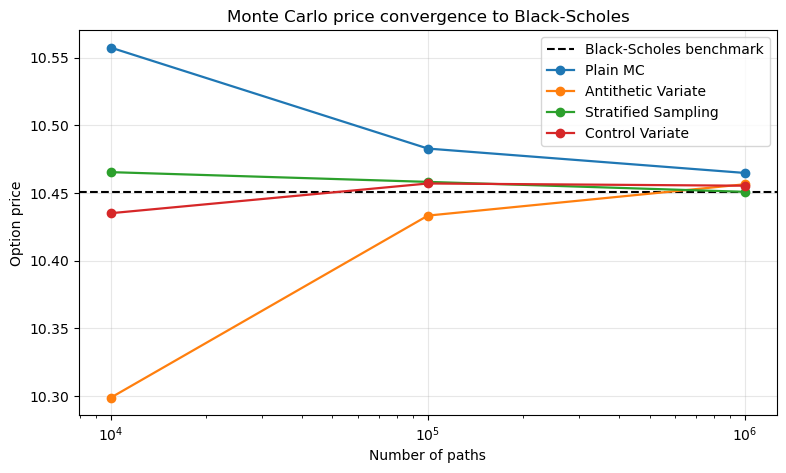

In [84]:
mc_plot_data = [
    ("Plain MC", plain_mc),
    ("Antithetic Variate", antithetic_mc),
    ("Stratified Sampling", stratified_mc),
    ("Control Variate", control_mc),
]

plt.figure(figsize=(9, 5))
plt.axhline(reference_price, color="black", linestyle="--", linewidth=1.5, label="Black-Scholes benchmark")

for label, df in mc_plot_data:
    plt.plot(
        df["No. of paths"],
        df["Price"],
        marker="o",
        linewidth=1.6,
        label=label,
    )

plt.xscale("log")
plt.xlabel("Number of paths")
plt.ylabel("Option price")
plt.title("Monte Carlo price convergence to Black-Scholes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURE_DIR / "european_mc_price_convergence.png", dpi=200, bbox_inches="tight")
plt.show()


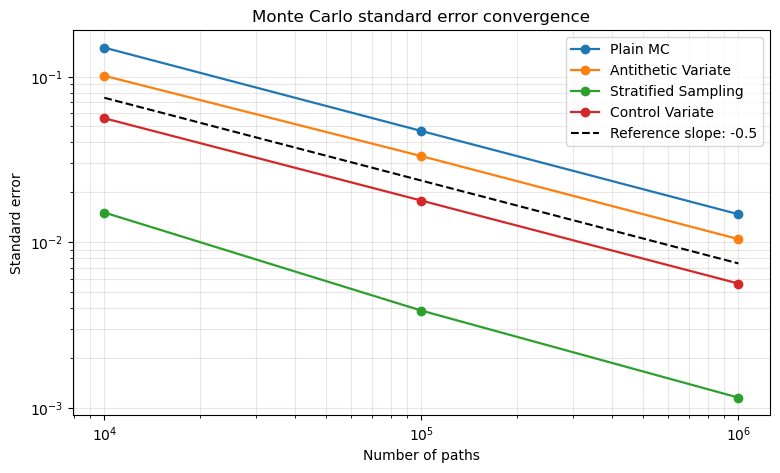

In [85]:
plt.figure(figsize=(9, 5))

for label, df in mc_plot_data:
    plt.plot(
        df["No. of paths"],
        df["Standard Error"],
        marker="o",
        linewidth=1.6,
        label=label,
    )

# Monte Carlo standard error scales like M^{-1/2}. The line is anchored
# to the first plain-MC standard error so the slope can be compared visually.
reference_paths = plain_mc["No. of paths"]
reference_stderr = (plain_mc["Standard Error"].iloc[0] - 0.075) * (reference_paths.iloc[0] / reference_paths) ** 0.5
plt.plot(
    reference_paths,
    reference_stderr,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Reference slope: -0.5",
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of paths")
plt.ylabel("Standard error")
plt.title("Monte Carlo standard error convergence")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig(FIGURE_DIR / "european_mc_standard_error.png", dpi=200, bbox_inches="tight")
plt.show()


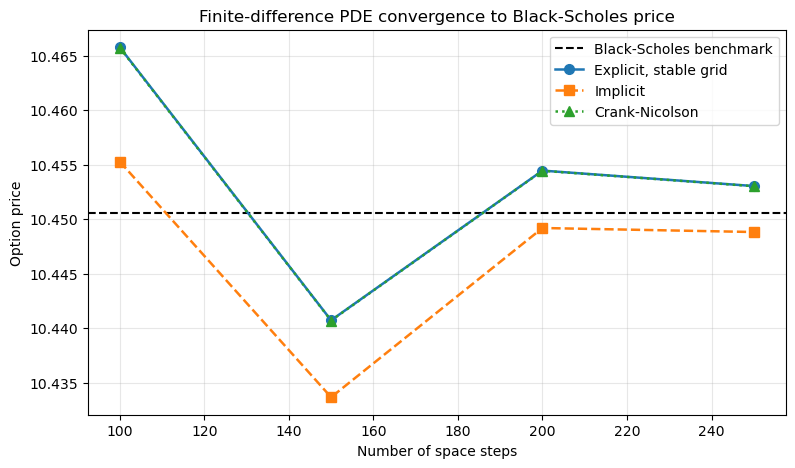

In [86]:
pde_plot_data = [
    ("Explicit, stable grid", explicit_pde, "o", "-"),
    ("Implicit", implicit_pde, "s", "--"),
    ("Crank-Nicolson", crank_nicolson_pde, "^", ":"),
]

plt.figure(figsize=(9, 5))
plt.axhline(reference_price, color="black", linestyle="--", linewidth=1.5, label="Black-Scholes benchmark")

for label, df, marker, linestyle in pde_plot_data:
    plt.plot(
        df["No. of space steps"],
        df["Price"],
        marker=marker,
        linestyle=linestyle,
        linewidth=1.8,
        markersize=7,
        label=label,
    )

plt.xlabel("Number of space steps")
plt.ylabel("Option price")
plt.title("Finite-difference PDE convergence to Black-Scholes price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURE_DIR / "european_pde_convergence.png", dpi=200, bbox_inches="tight")
plt.show()


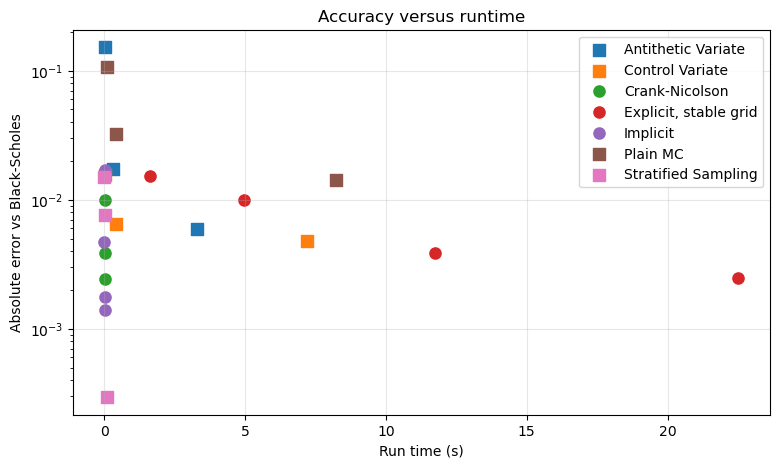

In [87]:
def _with_method(name, df, family, runtime_column="Run time"):
    result = df.copy()
    result["Method"] = name
    result["Family"] = family
    if runtime_column != "Run time":
        result = result.rename(columns={runtime_column: "Run time"})
    result["Absolute error"] = (result["Price"] - reference_price).abs()
    return result[["Method", "Family", "Run time", "Absolute error"]]

mc_efficiency = pd.concat(
    [_with_method(name, df, "MC", runtime_column="Run Time (s)") for name, df in mc_plot_data],
    ignore_index=True,
)

pde_efficiency = pd.concat(
    [_with_method(name, df, "PDE") for name, df, _, _ in pde_plot_data],
    ignore_index=True,
)

efficiency_data = pd.concat([mc_efficiency, pde_efficiency], ignore_index=True)
family_markers = {"MC": "s", "PDE": "o"}

plt.figure(figsize=(9, 5))
for method, group in efficiency_data.groupby("Method"):
    family = group["Family"].iloc[0]
    plt.scatter(
        group["Run time"],
        group["Absolute error"],
        label=method,
        marker=family_markers[family],
        s=65,
    )

plt.yscale("log")
plt.xlabel("Run time (s)")
plt.ylabel("Absolute error vs Black-Scholes")
plt.title("Accuracy versus runtime")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURE_DIR / "european_runtime_accuracy.png", dpi=200, bbox_inches="tight")
plt.show()
